<a href="https://colab.research.google.com/github/BorysZhyhalo/goit-rdb-hw-02/blob/main/hw2_movie_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2 — Relational Databases for Data Science

## Scenario: Movie Recommendation

The schema is designed for a movie recommendation ML system.
It includes business-domain entities, offline and online feature stores,
historical features, and training events for point-in-time correct model training.

## 1. ER Diagram

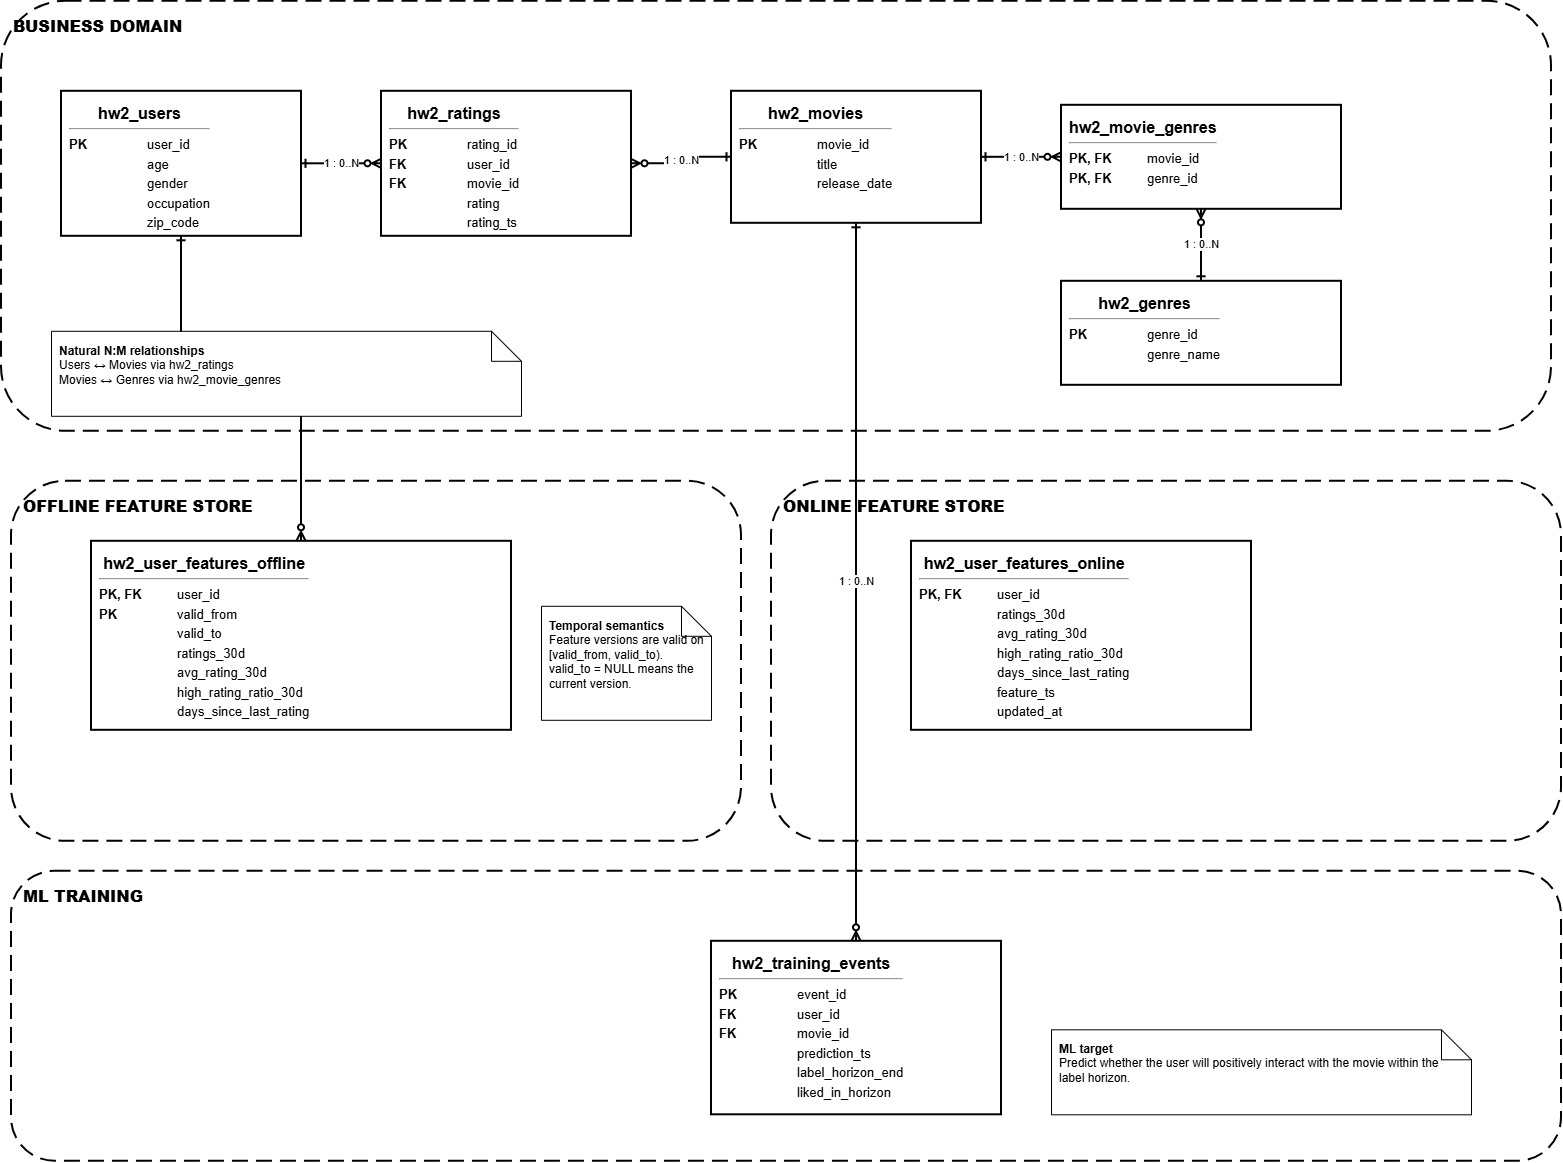

## 2. PostgreSQL DDL

In [43]:
# Install PostgreSQL server package for Colab
!pip install -q pgserver==0.1.4 --python-version 3.12 --only-binary=:all: --target=/usr/local/lib/python3.13/dist-packages

# Install Python packages for database access
!pip install -q sqlalchemy psycopg2-binary pandas

import pgserver
from sqlalchemy import create_engine, text

# Start PostgreSQL server
pg = pgserver.get_server('/tmp/pg_data')

# Create SQLAlchemy connection engine
engine = create_engine(pg.get_uri())

# Check database connection
with engine.connect() as conn:
    version = conn.execute(text("SELECT version()")).scalar()

print("PostgreSQL server started successfully")
print(version)

PostgreSQL server started successfully
PostgreSQL 16.2 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 10.2.1 20210130 (Red Hat 10.2.1-11), 64-bit


In [44]:
import pandas as pd

df = pd.read_sql("""
SELECT
    current_database() AS db,
    current_user AS usr,
    version() AS pg_version;
""", engine)

df

,db,usr,pg_version
0,postgres,postgres,"PostgreSQL 16.2 on x86_64-pc-linux-gnu, compil..."


In [45]:
with engine.begin() as conn:
    conn.execute(text("""
        SET TIME ZONE 'UTC';

        DROP TABLE IF EXISTS
            hw2_training_events,
            hw2_user_features_online,
            hw2_user_features_offline,
            hw2_movie_genres,
            hw2_ratings,
            hw2_genres,
            hw2_movies,
            hw2_users
        CASCADE;
    """))

In [46]:
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE hw2_users (
            user_id BIGINT
              PRIMARY KEY,

            age INTEGER
              NOT NULL CHECK (age > 0),

            gender VARCHAR(20)
              NOT NULL,

            occupation TEXT
              NOT NULL,

            zip_code VARCHAR(20)
        );

        CREATE TABLE hw2_movies (
            movie_id BIGINT
              PRIMARY KEY,

            title TEXT
              NOT NULL,

            release_date DATE
        );

        CREATE TABLE hw2_genres (
            genre_id INTEGER
              PRIMARY KEY,

            genre_name VARCHAR(100)
              NOT NULL UNIQUE
        );
    """))

print("Base tables created successfully.")

Base tables created successfully.


In [47]:
tables = pd.read_sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
      AND LEFT(table_name, 4) = 'hw2_'
    ORDER BY table_name;
""", engine)

tables

,table_name
0,hw2_genres
1,hw2_movies
2,hw2_users


In [48]:
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE hw2_ratings (
            rating_id BIGINT
                GENERATED BY DEFAULT AS IDENTITY
                PRIMARY KEY,

            user_id BIGINT NOT NULL
                REFERENCES hw2_users(user_id),

            movie_id BIGINT NOT NULL
                REFERENCES hw2_movies(movie_id),

            rating INTEGER NOT NULL
                CHECK (rating BETWEEN 1 AND 5),

            rating_ts TIMESTAMPTZ NOT NULL
        );
    """))

print("hw2_ratings created successfully.")

hw2_ratings created successfully.


In [49]:
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE hw2_movie_genres (
            movie_id BIGINT NOT NULL
                REFERENCES hw2_movies(movie_id),

            genre_id INTEGER NOT NULL
                REFERENCES hw2_genres(genre_id),

            PRIMARY KEY (movie_id, genre_id)
        );
    """))

print("hw2_movie_genres created successfully.")

hw2_movie_genres created successfully.


## 3. Normalization and Denormalization


## 4. Point-in-Time Correctness

## 5. Reflection